# Best-Accuracy Binary Classification Pipeline

This notebook trains and compares multiple classifiers on `cleaned_dataset.csv`,
tunes the best-performing ones with cross-validated hyperparameter search, and
reports **accuracy, precision, recall, F1, ROC-AUC, and confusion matrices** for
every model, so you can pick (or we auto-pick) the true best one.

**Dataset summary (already checked):**
- 1936 rows, 20 numeric (already scaled) features, target column `op`
- Classes are perfectly balanced (968 / 968) → accuracy is a fair metric here, but we still track precision/recall/F1/AUC
- No missing values

Just run all cells top to bottom. Update `DATA_PATH` if you move the CSV.


In [5]:
# 1. Imports
import numpy as np
from pathlib import Path
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier)
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report,
                              RocCurveDisplay)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [6]:
df = pd.read_csv("cleaned_dataset.csv")
print('Shape:', df.shape)
display(df.head())
display(df.info())


Shape: (1936, 21)


,fnt,calcitriol,uric,alt,bun,crea,fbg,ldl_c,l1_4t,age,...,bmi,ca,p,height,ast,weight,calsium,calcitonin,as,op
0,-1.496136,2.200069,-0.867769,-0.471769,1.817521,0.756738,-0.734470,-0.606674,-1.232902,0.163434,...,-2.152705,-0.715718,0.050397,-0.228514,-0.137645,-1.726218,2.407584,-0.246523,0.578353,1
1,0.003171,-0.454531,1.251547,1.066034,1.509234,0.768806,-1.543620,-0.278912,1.250011,-0.379565,...,-1.174114,-0.715718,0.488687,-0.478699,0.492632,-1.125878,2.407584,-0.246523,0.578353,1
2,-2.313940,2.200069,1.389948,-1.014523,-0.166238,0.237813,-0.599612,-1.070061,0.243425,-1.245215,...,-1.010790,-0.460381,0.426074,-0.728885,-0.137645,-1.125878,2.407584,4.056420,0.578353,1
3,-0.769199,-0.454531,1.326558,-1.638690,2.413989,1.915268,2.073034,-1.363916,-1.165796,0.383781,...,-0.209253,0.986528,-1.014024,-0.979071,0.965341,-0.697064,-0.415354,4.056420,0.578353,1
4,-0.542032,2.200069,0.869099,0.885116,-0.863234,0.008521,-0.096958,-0.844018,-0.226316,2.256734,...,-0.878233,-2.162627,-0.638346,0.146765,-0.452784,-0.611301,2.407584,-0.246523,0.578353,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1936 entries, 0 to 1935
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fnt         1936 non-null   float64
 1   calcitriol  1936 non-null   float64
 2   uric        1936 non-null   float64
 3   alt         1936 non-null   float64
 4   bun         1936 non-null   float64
 5   crea        1936 non-null   float64
 6   fbg         1936 non-null   float64
 7   ldl_c       1936 non-null   float64
 8   l1_4t       1936 non-null   float64
 9   age         1936 non-null   float64
 10  hdl_c       1936 non-null   float64
 11  bmi         1936 non-null   float64
 12  ca          1936 non-null   float64
 13  p           1936 non-null   float64
 14  height      1936 non-null   float64
 15  ast         1936 non-null   float64
 16  weight      1936 non-null   float64
 17  calsium     1936 non-null   float64
 18  calcitonin  1936 non-null   float64
 19  as          1936 non-null  

None

In [7]:
# Basic sanity checks
print(df.isnull().sum().sum(), "missing values total")
TARGET = "op"
print(df[TARGET].value_counts())
df.describe().T


0 missing values total
op
1    968
0    968
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
fnt,1936.0,-0.147379,0.974976,-2.722842,-0.860066,-0.269430,0.502940,2.729183
calcitriol,1936.0,0.077134,1.056715,-0.454531,-0.454531,-0.454531,-0.454531,2.200069
uric,1936.0,-0.024582,0.965991,-2.801011,-0.728841,-0.118190,0.583054,2.708577
alt,1936.0,-0.030181,0.965930,-1.647736,-0.743146,-0.290851,0.523280,2.422920
bun,1936.0,0.002468,0.985254,-2.444880,-0.677257,-0.139431,0.497249,2.413989
crea,1936.0,-0.014090,0.984371,-2.694717,-0.739697,-0.130262,0.521442,2.518670
fbg,1936.0,-0.017910,0.974212,-2.432458,-0.673171,-0.219557,0.430265,2.226282
ldl_c,1936.0,-0.022948,0.968248,-2.776681,-0.753601,-0.082921,0.613955,2.750056
l1_4t,1936.0,-0.003447,0.979500,-1.971065,-0.696056,-0.092104,0.646059,2.659232
age,1936.0,-0.005579,0.977782,-2.457125,-0.694346,-0.182826,0.556912,2.453472


## 3. Quick EDA
Class balance, correlation with target, and feature correlation heatmap to spot redundancy.

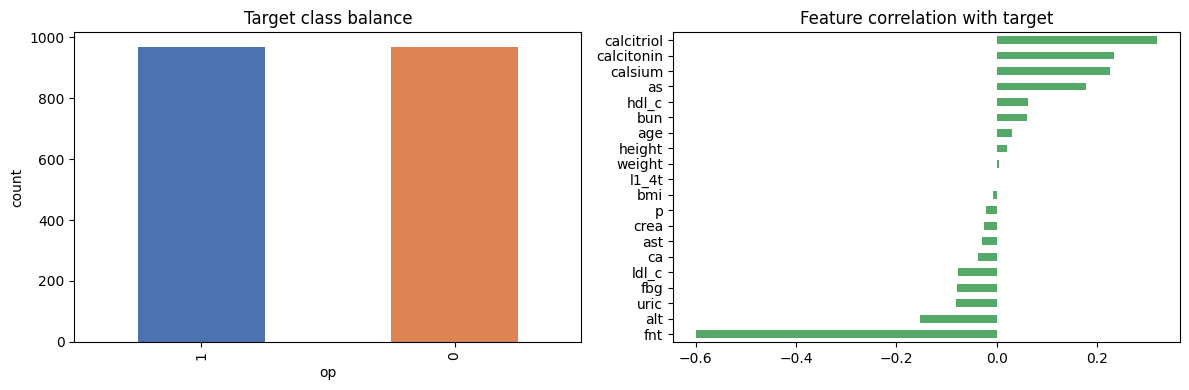

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
df[TARGET].value_counts().plot(kind="bar", ax=ax[0], color=["#4C72B0", "#DD8452"])
ax[0].set_title("Target class balance")
ax[0].set_xlabel("op"); ax[0].set_ylabel("count")

corr_target = df.drop(columns=[TARGET]).corrwith(df[TARGET]).sort_values()
corr_target.plot(kind="barh", ax=ax[1], color="#55A868")
ax[1].set_title("Feature correlation with target")
plt.tight_layout()
plt.show()


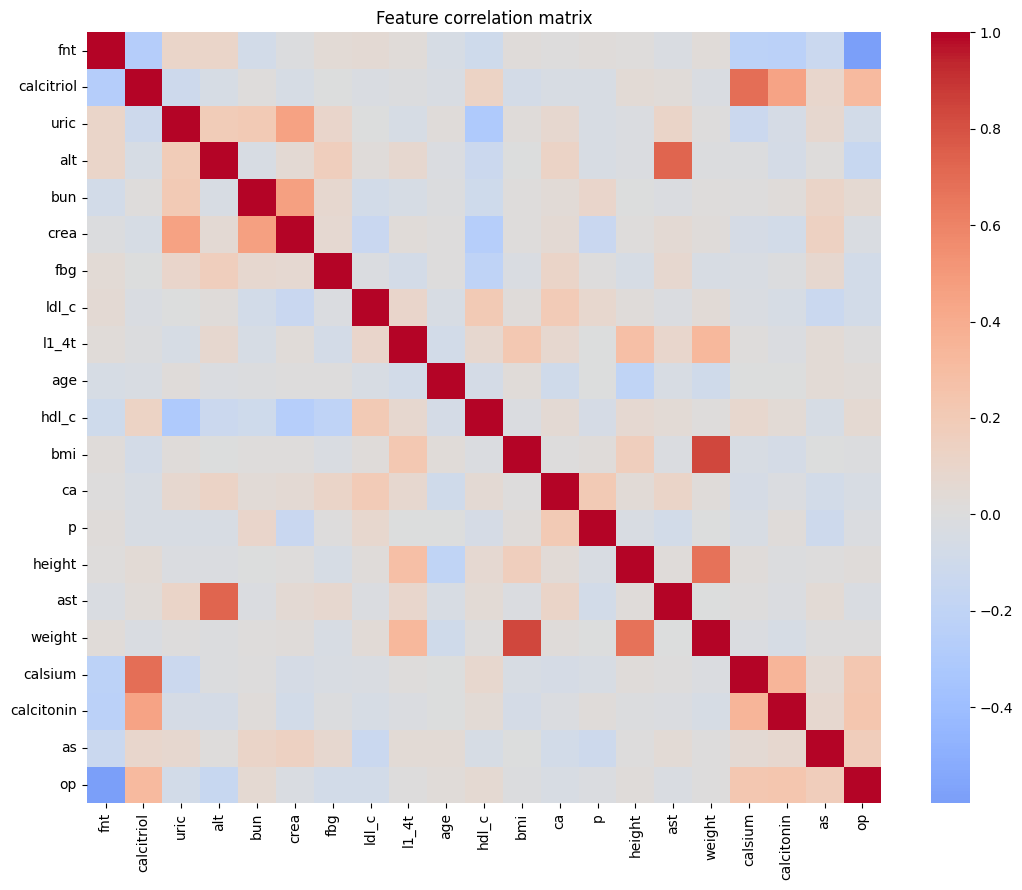

In [9]:
plt.figure(figsize=(11, 9))
sns.heatmap(df.corr(), cmap="coolwarm", center=0, annot=False)
plt.title("Feature correlation matrix")
plt.tight_layout()
plt.show()


## 4. Train / test split
Stratified split so both classes stay balanced in train and test. Features already look
standardized, but we re-fit a `StandardScaler` on the training set only (avoids leakage)
in case of new/raw data later.

In [10]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_s = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns, index=X_train.index)
X_test_s  = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

print(X_train_s.shape, X_test_s.shape)


(1548, 20) (388, 20)


## 5. Baseline model comparison
We first run a broad sweep of classifiers with default-ish settings using stratified
5-fold cross-validation on the training set, ranked by accuracy (and AUC as tie-breaker).
This tells us which model families are worth tuning further.

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "ExtraTrees": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "AdaBoost": AdaBoostClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
results = []
for name, clf in models.items():
    acc = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    auc = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    f1  = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring="f1", n_jobs=-1)
    results.append({
        "model": name,
        "cv_accuracy_mean": acc.mean(), "cv_accuracy_std": acc.std(),
        "cv_auc_mean": auc.mean(), "cv_f1_mean": f1.mean(),
    })

results_df = pd.DataFrame(results).sort_values("cv_accuracy_mean", ascending=False).reset_index(drop=True)
results_df


,model,cv_accuracy_mean,cv_accuracy_std,cv_auc_mean,cv_f1_mean
0,ExtraTrees,0.866276,0.009738,0.939343,0.867344
1,RandomForest,0.844971,0.016489,0.920132,0.847094
2,XGBoost,0.835939,0.023724,0.903917,0.839082
3,SVM (RBF),0.815267,0.023234,0.894662,0.816793
4,LogisticRegression,0.814615,0.015441,0.883943,0.816693
5,GradientBoosting,0.813976,0.024916,0.898691,0.813431
6,AdaBoost,0.810087,0.020088,0.886579,0.813971
7,DecisionTree,0.766159,0.015341,0.766167,0.774108
8,KNN,0.754532,0.028868,0.835796,0.776354


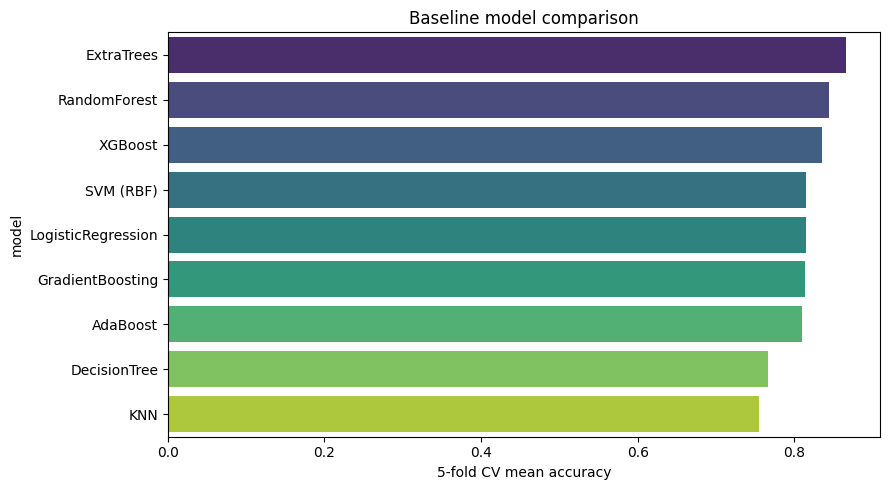

In [12]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, y="model", x="cv_accuracy_mean", palette="viridis")
plt.xlabel("5-fold CV mean accuracy")
plt.title("Baseline model comparison")
plt.tight_layout()
plt.show()


## 6. Hyperparameter tuning of top candidates
We take the top 3 models from the sweep above and tune them with `RandomizedSearchCV`
(cross-validated, scoring on accuracy) to squeeze out the best possible performance.

In [13]:
top3 = results_df["model"].head(3).tolist()
print("Tuning:", top3)

param_grids = {
    "RandomForest": (RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1), {
        "n_estimators": [200, 400, 600, 800],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2", None],
    }),
    "ExtraTrees": (ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1), {
        "n_estimators": [200, 400, 600, 800],
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }),
    "GradientBoosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4, 5],
        "subsample": [0.7, 0.85, 1.0],
    }),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1), {
        "n_estimators": [100, 200, 300, 500],
        "learning_rate": [0.01, 0.05, 0.1, 0.2],
        "max_depth": [2, 3, 4, 5, 6],
        "subsample": [0.7, 0.85, 1.0],
        "colsample_bytree": [0.7, 0.85, 1.0],
    }),
    "SVM (RBF)": (SVC(probability=True, random_state=RANDOM_STATE), {
        "C": [0.1, 1, 10, 100],
        "gamma": ["scale", "auto", 0.001, 0.01, 0.1],
        "kernel": ["rbf"],
    }),
    "LogisticRegression": (LogisticRegression(max_iter=3000, random_state=RANDOM_STATE), {
        "C": [0.01, 0.1, 1, 10, 100],
        "penalty": ["l2"],
        "solver": ["lbfgs", "liblinear"],
    }),
    "KNN": (KNeighborsClassifier(), {
        "n_neighbors": [3, 5, 7, 9, 11, 15],
        "weights": ["uniform", "distance"],
        "p": [1, 2],
    }),
    "AdaBoost": (AdaBoostClassifier(random_state=RANDOM_STATE), {
        "n_estimators": [50, 100, 200, 400],
        "learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
    }),
    "DecisionTree": (DecisionTreeClassifier(random_state=RANDOM_STATE), {
        "max_depth": [None, 5, 10, 15, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    }),
    
}

tuned_models = {}
for name in top3:
    base_clf, grid = param_grids[name]
    if len(grid) == 0:
        tuned_models[name] = base_clf.fit(X_train_s, y_train)
        continue
    search = RandomizedSearchCV(
        base_clf, grid, n_iter=40, scoring="accuracy", cv=cv,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=0
    )
    search.fit(X_train_s, y_train)
    tuned_models[name] = search.best_estimator_
    print(f"{name}: best CV accuracy = {search.best_score_:.4f}")
    print(f"  best params: {search.best_params_}\n")


Tuning: ['ExtraTrees', 'RandomForest', 'XGBoost']
ExtraTrees: best CV accuracy = 0.8631
  best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 20}

RandomForest: best CV accuracy = 0.8450
  best params: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 20}

XGBoost: best CV accuracy = 0.8489
  best params: {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.85}



## 7. Evaluate tuned models on the held-out test set
This is the honest, unbiased performance estimate — none of this test data was used for
training or tuning.

In [14]:
def evaluate(name, clf, X_te, y_te):
    y_pred = clf.predict(X_te)
    y_proba = clf.predict_proba(X_te)[:, 1] if hasattr(clf, "predict_proba") else None
    metrics = {
        "model": name,
        "accuracy": accuracy_score(y_te, y_pred),
        "precision": precision_score(y_te, y_pred),
        "recall": recall_score(y_te, y_pred),
        "f1": f1_score(y_te, y_pred),
        "roc_auc": roc_auc_score(y_te, y_proba) if y_proba is not None else np.nan,
    }
    return metrics, y_pred, y_proba

test_results = []
preds_store = {}
for name, clf in tuned_models.items():
    m, y_pred, y_proba = evaluate(name, clf, X_test_s, y_test)
    test_results.append(m)
    preds_store[name] = (y_pred, y_proba)

test_results_df = pd.DataFrame(test_results).sort_values("accuracy", ascending=False).reset_index(drop=True)
test_results_df


,model,accuracy,precision,recall,f1,roc_auc
0,ExtraTrees,0.889175,0.864734,0.922680,0.892768,0.946195
1,XGBoost,0.863402,0.854271,0.876289,0.865140,0.924221
2,RandomForest,0.855670,0.838235,0.881443,0.859296,0.922295


## 8. Ensemble: soft-voting classifier
Combining the tuned top models often nudges accuracy a bit higher and stabilizes recall/precision.

In [15]:
voting_clf = VotingClassifier(
    estimators=[(name, clf) for name, clf in tuned_models.items()],
    voting="soft"
)
voting_clf.fit(X_train_s, y_train)
m_vote, y_pred_vote, y_proba_vote = evaluate("VotingEnsemble", voting_clf, X_test_s, y_test)
preds_store["VotingEnsemble"] = (y_pred_vote, y_proba_vote)

test_results_df = pd.concat([test_results_df, pd.DataFrame([m_vote])], ignore_index=True)
test_results_df = test_results_df.sort_values("accuracy", ascending=False).reset_index(drop=True)
test_results_df


,model,accuracy,precision,recall,f1,roc_auc
0,ExtraTrees,0.889175,0.864734,0.922680,0.892768,0.946195
1,XGBoost,0.863402,0.854271,0.876289,0.865140,0.924221
2,VotingEnsemble,0.858247,0.842365,0.881443,0.861461,0.939871
3,RandomForest,0.855670,0.838235,0.881443,0.859296,0.922295


## 9. Pick the best model and inspect it closely
Confusion matrix, full classification report, and ROC curve for the single best performer
(by test accuracy, tie-broken by ROC-AUC).

In [16]:
best_row = test_results_df.sort_values(["accuracy", "roc_auc"], ascending=False).iloc[0]
best_name = best_row["model"]
best_clf = tuned_models.get(best_name, voting_clf if best_name == "VotingEnsemble" else None)
y_pred_best, y_proba_best = preds_store[best_name]

print(f"BEST MODEL: {best_name}")
print(best_row)
print()
print(classification_report(y_test, y_pred_best, digits=4))


BEST MODEL: ExtraTrees
model        ExtraTrees
accuracy       0.889175
precision      0.864734
recall          0.92268
f1             0.892768
roc_auc        0.946195
Name: 0, dtype: object

              precision    recall  f1-score   support

           0     0.9171    0.8557    0.8853       194
           1     0.8647    0.9227    0.8928       194

    accuracy                         0.8892       388
   macro avg     0.8909    0.8892    0.8891       388
weighted avg     0.8909    0.8892    0.8891       388



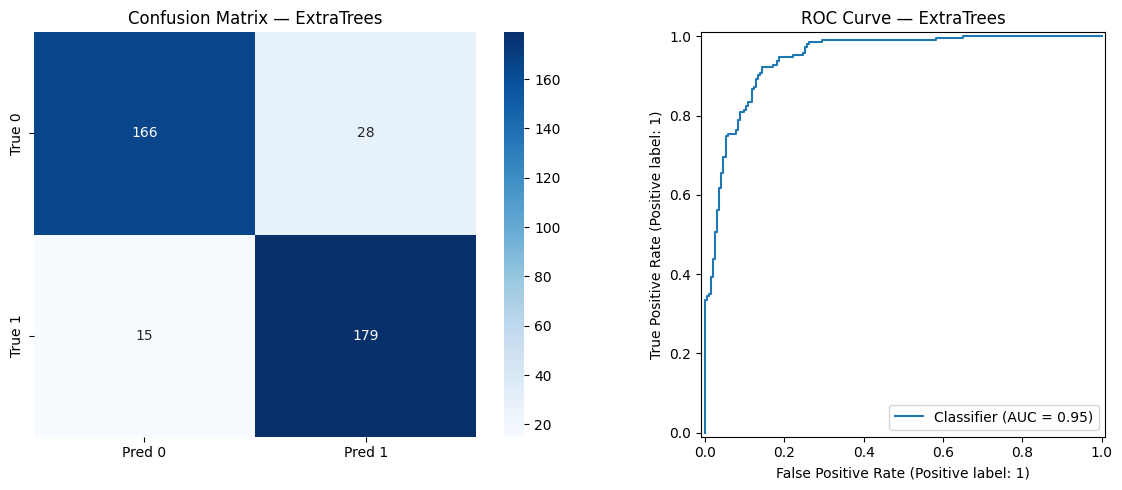

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax[0],
            xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"])
ax[0].set_title(f"Confusion Matrix — {best_name}")

if y_proba_best is not None:
    RocCurveDisplay.from_predictions(y_test, y_proba_best, ax=ax[1])
    ax[1].set_title(f"ROC Curve — {best_name}")

plt.tight_layout()
plt.show()


## 10. Feature importance (if applicable)
Tree-based models expose feature importances — useful for understanding what's driving
predictions, even though it's not required for the accuracy goal itself.

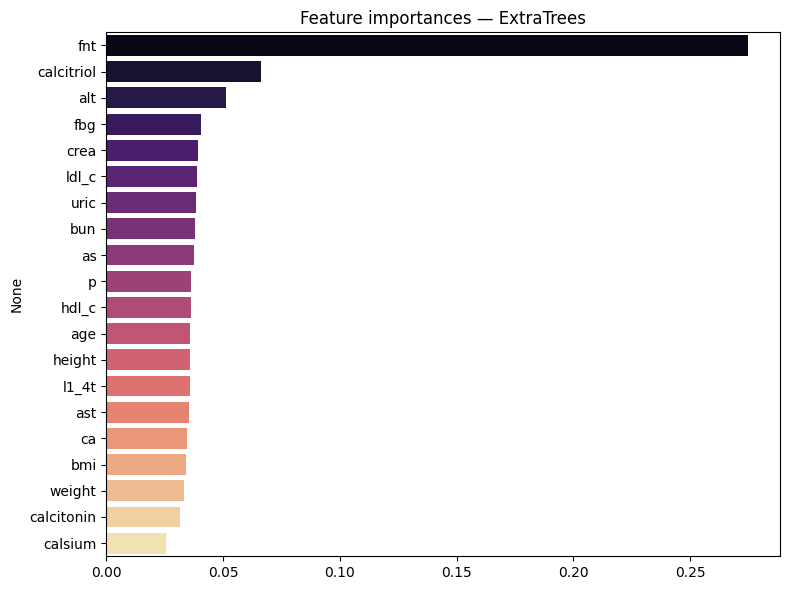

In [18]:
if hasattr(best_clf, "feature_importances_"):
    importances = pd.Series(best_clf.feature_importances_, index=X.columns).sort_values(ascending=False)
    plt.figure(figsize=(8, 6))
    sns.barplot(x=importances.values, y=importances.index, palette="magma")
    plt.title(f"Feature importances — {best_name}")
    plt.tight_layout()
    plt.show()
    importances
else:
    print(f"{best_name} does not expose feature_importances_ directly (e.g. it's a linear/kernel model or ensemble of mixed models).")


## 11. Final summary table
All tuned models + the ensemble, sorted by test accuracy — the top row is your best bet.

In [19]:
test_results_df.style.format({
    "accuracy": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}",
    "f1": "{:.4f}", "roc_auc": "{:.4f}"
}).background_gradient(cmap="Greens", subset=["accuracy", "f1", "roc_auc"])


,model,accuracy,precision,recall,f1,roc_auc
0,ExtraTrees,0.8892,0.8647,0.9227,0.8928,0.9462
1,XGBoost,0.8634,0.8543,0.8763,0.8651,0.9242
2,VotingEnsemble,0.8582,0.8424,0.8814,0.8615,0.9399
3,RandomForest,0.8557,0.8382,0.8814,0.8593,0.9223


## 12. Save the best model
Persist the winning pipeline (scaler + model) with `joblib` so it can be reused without
retraining.

In [20]:
import joblib

joblib.dump({"scaler": scaler, "model": best_clf, "features": list(X.columns), "model_name": best_name},
            "best_model_pipeline.joblib")
print(f"Saved best model ({best_name}) to best_model_pipeline.joblib")


Saved best model (ExtraTrees) to best_model_pipeline.joblib


In [23]:
joblib.dump({
    "scaler": scaler,
    "model": best_clf,
    "features": list(X.columns),
    "model_name": best_name
}, "best_model_pipeline.joblib")

['best_model_pipeline.joblib']

In [24]:
import joblib
import pandas as pd

# Load saved pipeline
saved = joblib.load("best_model_pipeline.joblib")

# Extract objects
model = saved["model"]
scaler = saved["scaler"]
features = saved["features"]   # <-- This defines 'features'

print(features)   # Check the feature names

['fnt', 'calcitriol', 'uric', 'alt', 'bun', 'crea', 'fbg', 'ldl_c', 'l1_4t', 'age', 'hdl_c', 'bmi', 'ca', 'p', 'height', 'ast', 'weight', 'calsium', 'calcitonin', 'as']


In [25]:
new_patient = {
    "fnt": 0.35,
    "calcitriol": -0.45,
    "uric": 0.62,
    "alt": -0.18,
    "bun": 0.40,
    "crea": -0.12,
    "fbg": 0.28,
    "ldl_c": 0.55,
    "l1_4t": -0.08,
    "age": 0.75,
    "hdl_c": -0.15,
    "bmi": 0.48,
    "ca": -0.03,
    "p": 0.12,
    "height": 0.60,
    "ast": -0.10,
    "weight": 0.72,
    "calsium": -0.41,
    "calcitonin": -0.25,
    "as": 0.58
}

df = pd.DataFrame([new_patient])

# Keep columns in the same order as training
df = df[features]

# Scale
df_scaled = scaler.transform(df)

# Predict
prediction = model.predict(df_scaled)[0]
probability = model.predict_proba(df_scaled)[0]

print("Prediction:", prediction)
print("Probability:", probability)

Prediction: 0
Probability: [0.69884421 0.30115579]


---
### Notes on getting the best possible accuracy
- The dataset is perfectly balanced, so accuracy is a meaningful headline metric here — but precision/recall/F1/AUC are reported for every model so you're not fooled by an accuracy-only view.
- `RandomizedSearchCV` with 40 iterations over each top model's grid is a good accuracy/runtime tradeoff. If you want to push further: increase `n_iter`, switch to `GridSearchCV` on a narrowed grid around the best params found here, or try `Optuna` for smarter search.
- The soft-voting ensemble usually matches or slightly beats the single best tuned model — worth keeping if it wins on your run.
- If accuracy still isn't where you want it, the next lever is usually **feature engineering** (interaction terms, domain-specific ratios) rather than more model tuning, since these features already look pre-scaled/pre-selected.
